# Problem Statement
The mtcars dataset contains information about different car models and their technical specifications such as mileage, horsepower, weight, number of cylinders, and transmission type.

In [1]:
import numpy as np
import pandas as pd
from pydataset import data
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
mtcars = data('mtcars')
mtcars.head(5)

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


# Part 1: Load and Understand the Data
Import the dataset into a Pandas DataFrame.

Display the first 5 rows.

Check:
* shape of the dataset
* column names
* data types
* summary statistics

Check whether there are any missing values.

In [3]:
mtcars.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32 entries, Mazda RX4 to Volvo 142E
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   mpg     32 non-null     float64
 1   cyl     32 non-null     int64  
 2   disp    32 non-null     float64
 3   hp      32 non-null     int64  
 4   drat    32 non-null     float64
 5   wt      32 non-null     float64
 6   qsec    32 non-null     float64
 7   vs      32 non-null     int64  
 8   am      32 non-null     int64  
 9   gear    32 non-null     int64  
 10  carb    32 non-null     int64  
dtypes: float64(5), int64(6)
memory usage: 3.0+ KB


In [4]:
mtcars.shape

(32, 11)

In [5]:
# data types in each column
mtcars.dtypes

mpg     float64
cyl       int64
disp    float64
hp        int64
drat    float64
wt      float64
qsec    float64
vs        int64
am        int64
gear      int64
carb      int64
dtype: object

In [6]:
mtcars.describe()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.0000
mean,20.090625,6.187500,230.721875,146.687500,3.596563,3.217250,17.848750,0.437500,0.406250,3.687500,2.8125
std,6.026948,1.785922,123.938694,68.562868,0.534679,0.978457,1.786943,0.504016,0.498991,0.737804,1.6152
min,10.400000,4.000000,71.100000,52.000000,2.760000,1.513000,14.500000,0.000000,0.000000,3.000000,1.0000
25%,15.425000,4.000000,120.825000,96.500000,3.080000,2.581250,16.892500,0.000000,0.000000,3.000000,2.0000
50%,19.200000,6.000000,196.300000,123.000000,3.695000,3.325000,17.710000,0.000000,0.000000,4.000000,2.0000
75%,22.800000,8.000000,326.000000,180.000000,3.920000,3.610000,18.900000,1.000000,1.000000,4.000000,4.0000
max,33.900000,8.000000,472.000000,335.000000,4.930000,5.424000,22.900000,1.000000,1.000000,5.000000,8.0000


In [7]:
print(mtcars.isnull().sum(axis=0), '\n\n', mtcars.isnull().mean())

mpg     0
cyl     0
disp    0
hp      0
drat    0
wt      0
qsec    0
vs      0
am      0
gear    0
carb    0
dtype: int64 

 mpg     0.0
cyl     0.0
disp    0.0
hp      0.0
drat    0.0
wt      0.0
qsec    0.0
vs      0.0
am      0.0
gear    0.0
carb    0.0
dtype: float64


In [8]:
mtcars.duplicated().sum()

np.int64(0)

### Column names
Dataset describes a sample of cars and their aspects:
* mpg = Miles/(US) gallon
* cyl = Number of cylinders
* disp = Displacement (cu.in.)
* hp = Gross horsepower
* drat = Rear axle ratio or differential ratio
* wt = Weight in 1000 lbs
* qsec = 1/4 mile time
* vs = Engine (0 = V-shaped, 1 = straight)
* am = Transmission (0 = automatic, 1 = manual)
* gear = Number of forward gears
* carb = number of carburetors
###### https://www.rdocumentation.org/packages/datasets/versions/3.6.2/topics/mtcars

In [9]:
# creating a copy for backup
mtcars_copy = mtcars.copy()

In [10]:
mtcars[['hp', 'mpg', 'wt']].describe()

,hp,mpg,wt
count,32.000000,32.000000,32.000000
mean,146.687500,20.090625,3.217250
std,68.562868,6.026948,0.978457
min,52.000000,10.400000,1.513000
25%,96.500000,15.425000,2.581250
50%,123.000000,19.200000,3.325000
75%,180.000000,22.800000,3.610000
max,335.000000,33.900000,5.424000


# Part 2
Find:
* average mileage (mpg)
* maximum horsepower (hp)
* minimum and maximum weight (wt)

Count how many cars have:
* 4 cylinders
* 6 cylinders
* 8 cylinders

Find the average mileage for each cylinder category using groupby().

In [11]:
# Average mileage
print("Average mileage: ", mtcars['mpg'].mean())

Average mileage:  20.090625000000003


In [12]:
# Maximum horsepower
print("Maximum Horsepower: ", mtcars['hp'].max(), '\nCar: ', mtcars['hp'].idxmax())
mtcars[mtcars.index.str.contains('Maserati Bora')]

Maximum Horsepower:  335 
Car:  Maserati Bora


,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
Maserati Bora,15.0,8,301.0,335,3.54,3.57,14.6,0,1,5,8


In [13]:
#Weight
print("Lightest Car: ", mtcars['wt'].min(), "lb ", mtcars['wt'].idxmin())
print("Heaviest Car: ", mtcars['wt'].max(), "lb ", mtcars['wt'].idxmax())

Lightest Car:  1.513 lb  Lotus Europa
Heaviest Car:  5.424 lb  Lincoln Continental


In [14]:
# cylinders
print("Count of cars in each cylinder category and their average mpg\n")
mtcars.groupby('cyl')['mpg'].agg(['count', 'mean'])

Count of cars in each cylinder category and their average mpg



,count,mean
cyl,,
4,11,26.663636
6,7,19.742857
8,14,15.100000


# Part 3

### Part 3: Intermediate Analysis
Compare average mileage by:
* transmission type (am)
* number of gears (gear)

Create a pivot table showing average mpg by cyl and am.

Create a new column:
* efficiency where cars with mpg > 20 are labeled "High" and others "Low"

Use map() to convert:
* am: 0 = Automatic, 1 = Manual
* vs: 0 = V-shaped, 1 = Straight


#### Data Cleaning
converting transmission and vshaped

In [15]:
mtcars_copy = mtcars.copy()

In [16]:
# am => 0 = auto, 1 = manual
mtcars['am'] = mtcars_copy['am'].map({0:'Automatic', 1:'Manual'})
# vs => 0 = vshaped, 1 = straight
mtcars['vs'] = mtcars_copy['vs'].map({0:'V-shaped', 1:'Straight'})
mtcars.head()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,V-shaped,Manual,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,V-shaped,Manual,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,Straight,Manual,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,Straight,Automatic,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,V-shaped,Automatic,3,2


### Adding 'Efficiency' column
where mpg > 20 = 'high' else low

In [17]:
# efficiency
mtcars['efficiency'] = mtcars['mpg'].apply(lambda x: 'High' if x > 20 else 'Low')
mtcars.head()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,efficiency
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,V-shaped,Manual,4,4,High
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,V-shaped,Manual,4,4,High
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,Straight,Manual,4,1,High
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,Straight,Automatic,3,1,High
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,V-shaped,Automatic,3,2,Low


In [18]:
print("Average mileage per transmission:\n")
mtcars.groupby('am')['mpg'].agg(['mean'])

Average mileage per transmission:



,mean
am,
Automatic,17.147368
Manual,24.392308


In [19]:
print("Average mileage per total gear\n")
mtcars.groupby('gear')['mpg'].agg(['mean'])

Average mileage per total gear



,mean
gear,
3,16.106667
4,24.533333
5,21.380000


In [20]:
# Average mpg by gear and cyl
mtcars.pivot_table(values='mpg', index=['gear', 'cyl'], observed=True, aggfunc='mean').reset_index()

,gear,cyl,mpg
0,3,4,21.500
1,3,6,19.750
2,3,8,15.050
3,4,4,26.925
4,4,6,19.750
5,5,4,28.200
6,5,6,19.700
7,5,8,15.400


## Categorizing cars by HP and weight class

In [21]:
## Putting important car aspects into bins
# HP
mtcars['Power Class'] = pd.cut(mtcars['hp'], bins=[0, 100, 180, 250, mtcars['hp'].max()], labels=['Very Low', 'Low', 'Medium', 'High'], include_lowest=True)
# Weight
mtcars['Weight Class'] = pd.cut(mtcars['wt'], bins=[0, 2, 3.2, 4, mtcars['mpg'].max()], labels=['Light', 'Medium', 'Heavy', 'Very Heavy'], include_lowest=True)
mtcars.head(mtcars.shape[0])

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,efficiency,Power Class,Weight Class
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,V-shaped,Manual,4,4,High,Low,Medium
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,V-shaped,Manual,4,4,High,Low,Medium
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,Straight,Manual,4,1,High,Very Low,Medium
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,Straight,Automatic,3,1,High,Low,Heavy
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,V-shaped,Automatic,3,2,Low,Low,Heavy
Valiant,18.1,6,225.0,105,2.76,3.460,20.22,Straight,Automatic,3,1,Low,Low,Heavy
Duster 360,14.3,8,360.0,245,3.21,3.570,15.84,V-shaped,Automatic,3,4,Low,Medium,Heavy
Merc 240D,24.4,4,146.7,62,3.69,3.190,20.00,Straight,Automatic,4,2,High,Very Low,Medium
Merc 230,22.8,4,140.8,95,3.92,3.150,22.90,Straight,Automatic,4,2,High,Very Low,Medium
Merc 280,19.2,6,167.6,123,3.92,3.440,18.30,Straight,Automatic,4,4,Low,Low,Heavy


# Part 4: Data Visualization

In [22]:
mtcars.head()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,efficiency,Power Class,Weight Class
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,V-shaped,Manual,4,4,High,Low,Medium
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,V-shaped,Manual,4,4,High,Low,Medium
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,Straight,Manual,4,1,High,Very Low,Medium
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,Straight,Automatic,3,1,High,Low,Heavy
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,V-shaped,Automatic,3,2,Low,Low,Heavy


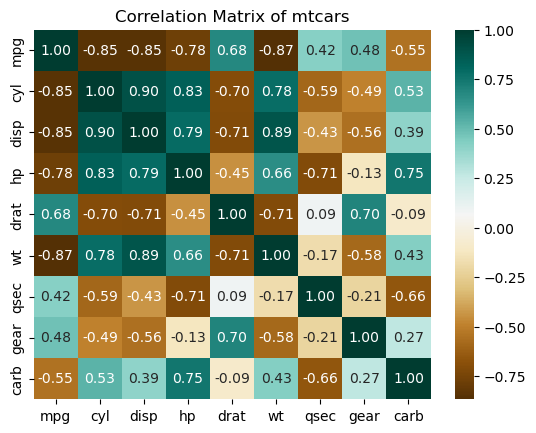

In [23]:
corr = mtcars.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='BrBG', fmt=".2f")
plt.title("Correlation Matrix of mtcars")
plt.show()

The heatmap shows am overview correlation matrix of each variable and their relations to other variables. We can determine that the darker spots have negative correlation and lighter spots have positive correlation. The strongest negative spots are typically ones pairing mpg with cylinders, displacement, horsepower, and weight, and qsec and hp. Positive spots are weight and displacements, carburetor and horsepower, and carburetors helping horsepower. The weakest correlation is drat and qsec, which means that rear axle ratio isnt affecting quarter mile speed tests.

# Observing individual correlations between Mileage and Horsepower, displacement, Rear Axle Ratio, and Quarter Mile Time

Text(0.5, 1.0, 'Mileage vs Horsepower')

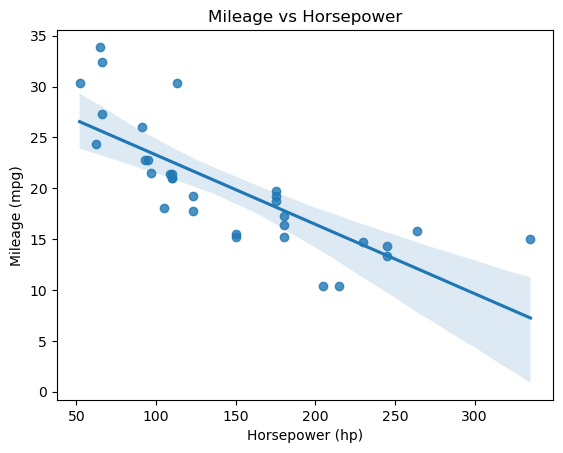

In [24]:
# mpg vs hp
ax = sns.regplot(data=mtcars[['mpg', 'hp']].sort_values(by='hp'), x='hp', y='mpg')
plt.ylabel("Mileage (mpg)")
plt.xlabel("Horsepower (hp)")
ax.set_title("Mileage vs Horsepower")

There is a strong negative correlation between horsepower and mileage. The higher the power, the more fuel is being consumed.

Text(0.5, 1.0, 'Mileage vs Displacement')

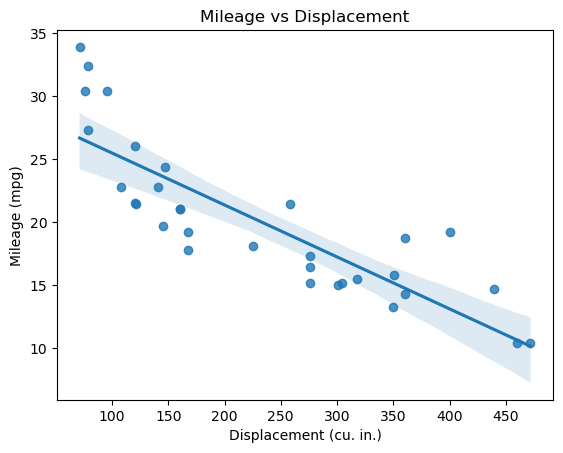

In [25]:
# mpg vs displacement
ax = sns.regplot(data=mtcars[['mpg', 'disp']].sort_values(by='disp'), x='disp', y='mpg')
plt.ylabel("Mileage (mpg)")
plt.xlabel("Displacement (cu. in.)")
ax.set_title("Mileage vs Displacement")

There is also a strong negative correlation between displacement and mileage. Higher displacement produces more power (shown by the chart below), and so it consumes more fuel.

Text(0.5, 1.0, 'Showing the relation between Horsepower and displacement')

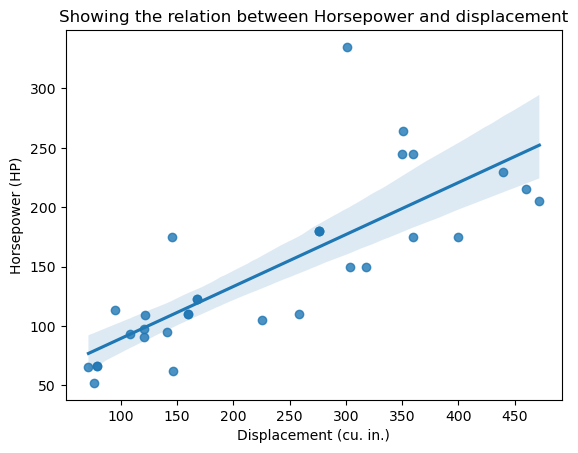

In [26]:
ax = sns.regplot(data=mtcars[['hp', 'disp']].sort_values(by='disp'), x='disp', y='hp')
plt.ylabel("Horsepower (HP)")
plt.xlabel("Displacement (cu. in.)")
ax.set_title("Showing the relation between Horsepower and displacement")

Text(0.5, 1.0, 'Mileage vs Weight')

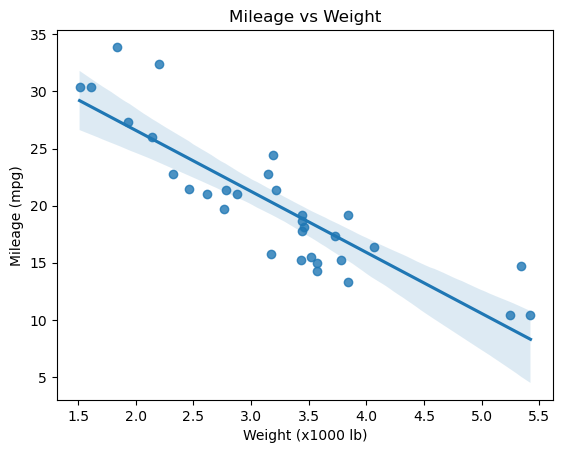

In [27]:
# mpg vs weight
ax = sns.regplot(data=mtcars[['mpg', 'wt']].sort_values(by='wt'), x='wt', y='mpg')
plt.ylabel("Mileage (mpg)")
plt.xlabel("Weight (x1000 lb)")
ax.set_title("Mileage vs Weight")

Weight is negatively correlated to mileage, as heavier cars need more power to accelerate.

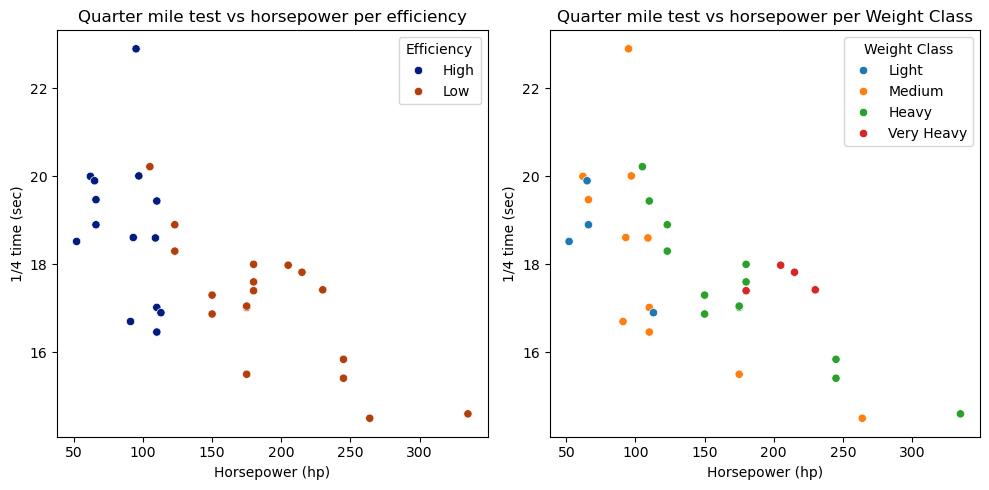

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# efficient cars vs non efficient cars
sns.scatterplot(data=mtcars, x='hp', y='qsec', hue='efficiency', ax=axes[0], palette='dark')
axes[0].set_title('Quarter mile test vs horsepower per efficiency')
axes[0].set_ylabel('1/4 time (sec)')
axes[0].set_xlabel('Horsepower (hp)')
axes[0].legend(title='Efficiency')

# differentiating by weight class
sns.scatterplot(data=mtcars, x='hp', y='qsec', hue='Weight Class', ax=axes[1], palette='tab10')
axes[1].set_title('Quarter mile test vs horsepower per Weight Class')
axes[1].set_ylabel('1/4 time (sec)')
axes[1].set_xlabel('Horsepower (hp)')
axes[1].legend(title='Weight Class')

plt.tight_layout() # Optimizes spacing
plt.show()

In [29]:
print(mtcars.loc["Honda Civic"])
mtcars.nlargest(5, 'qsec')


mpg                 30.4
cyl                    4
disp                75.7
hp                    52
drat                4.93
wt                 1.615
qsec               18.52
vs              Straight
am                Manual
gear                   4
carb                   2
efficiency          High
Power Class     Very Low
Weight Class       Light
Name: Honda Civic, dtype: object


,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,efficiency,Power Class,Weight Class
Merc 230,22.8,4,140.8,95,3.92,3.150,22.90,Straight,Automatic,4,2,High,Very Low,Medium
Valiant,18.1,6,225.0,105,2.76,3.460,20.22,Straight,Automatic,3,1,Low,Low,Heavy
Toyota Corona,21.5,4,120.1,97,3.70,2.465,20.01,Straight,Automatic,3,1,High,Very Low,Medium
Merc 240D,24.4,4,146.7,62,3.69,3.190,20.00,Straight,Automatic,4,2,High,Very Low,Medium
Toyota Corolla,33.9,4,71.1,65,4.22,1.835,19.90,Straight,Manual,4,1,High,Very Low,Light


The scatterplot shows the trends in quarter mile test as horsepower increase. The Efficiency groups diverge around 110 hp. The notable point here is the slowest car to cross 1/4 mi is the mercedes 230.

Text(0.5, 1.0, 'Qsec vs Weight')

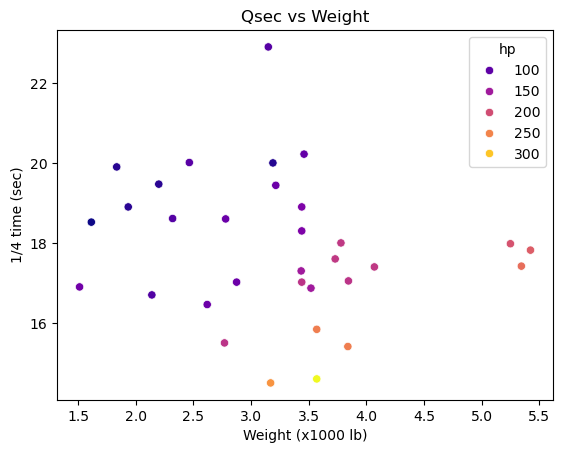

In [41]:
# weight vs qsec
sns.scatterplot(data=mtcars, x='wt', y='qsec', hue='hp', palette="plasma")
plt.ylabel("1/4 time (sec)")
plt.xlabel("Weight (x1000 lb)")
plt.title("Qsec vs Weight")

This graph also shows the scatterplot of quarter mile time vs weight, in addition to color gradient in power.

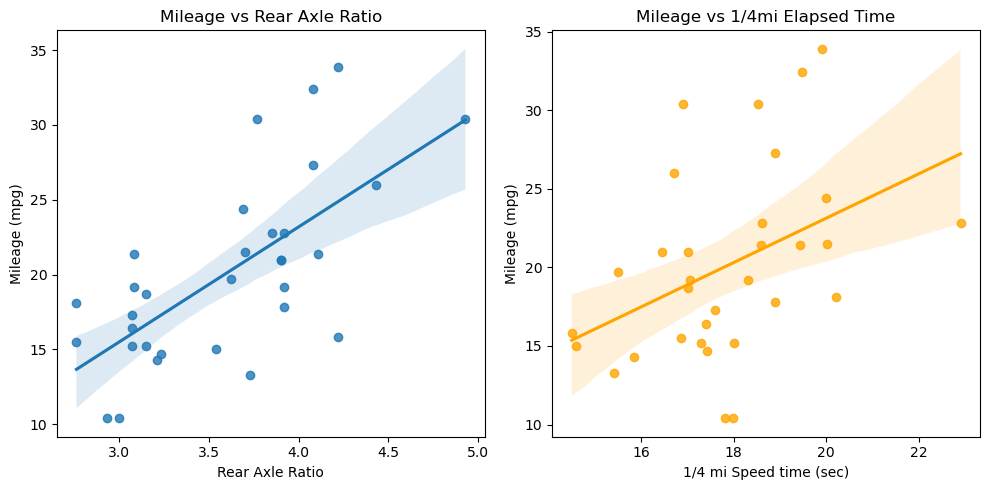

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# mpg vs drat
sns.regplot(data=mtcars[['mpg', 'drat']].sort_values(by='drat'), x='drat', y='mpg', ax=axes[0])
axes[0].set_ylabel("Mileage (mpg)")
axes[0].set_xlabel("Rear Axle Ratio")
axes[0].set_title("Mileage vs Rear Axle Ratio")

# mpg vs quarter mile elapse time
sns.regplot(data=mtcars[['mpg', 'qsec']].sort_values(by='qsec'), x='qsec', y='mpg', ax=axes[1], color='orange')
axes[1].set_ylabel("Mileage (mpg)")
axes[1].set_xlabel("1/4 mi Speed time (sec)")
axes[1].set_title("Mileage vs 1/4mi Elapsed Time")

plt.tight_layout() # Optimizes spacing
plt.show()

In [32]:
# Investigating differential ratio affects mpg 
mtcars.nlargest(5, 'drat')

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,efficiency,Power Class,Weight Class
Honda Civic,30.4,4,75.7,52,4.93,1.615,18.52,Straight,Manual,4,2,High,Very Low,Light
Porsche 914-2,26.0,4,120.3,91,4.43,2.140,16.70,V-shaped,Manual,5,2,High,Very Low,Medium
Toyota Corolla,33.9,4,71.1,65,4.22,1.835,19.90,Straight,Manual,4,1,High,Very Low,Light
Ford Pantera L,15.8,8,351.0,264,4.22,3.170,14.50,V-shaped,Manual,5,4,Low,High,Medium
Volvo 142E,21.4,4,121.0,109,4.11,2.780,18.60,Straight,Manual,4,2,High,Low,Medium


Rear axle ratio (diff ratio) vs mileage and the quarter mile time vs mileage graphs show low correlation. The interesting point here is the car with the highest diff ratio, which is the Honda Civic with the lowest hp. Compared to the Civic with 52 hp, the Mercedes has almost twice the power but heavier.

### Transmission types

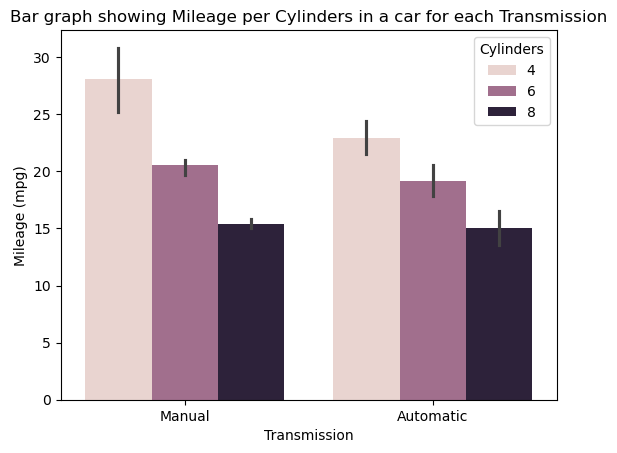

In [33]:
# barplot - transmission type
ax = sns.barplot(data=mtcars, x='am', y='mpg', hue='cyl')
ax.set_title('Bar graph showing Mileage per Cylinders in a car for each Transmission')
plt.ylabel('Mileage (mpg)')
plt.xlabel('Transmission')
plt.legend(title='Cylinders')

The bar graph above shows a comparison of mileage between transmission types and cylinders. It is apparent that higher cylinders mean lower mileage. The error rate is also noticeably larger in 4 cylinder manual cars.

# Part 5 - Insights and Conclusion

The graphs show a clear trend in mileage, where heavier and more powerful cars tend to consume more fuel.

Some graphs show a weaker correlation, which means that those variables are more nuanced and need more data.

Mileage in reality has a negative correlation to diff ratio, but the dataset shows otherwise. This might be due to giving the Civic higher ratio to give more speed to the otherwise low hp car.

The number of cylinders increase power while decreasing mileage. The mileage is also better among manual transmission cars in general.

The power of a car doesn't signify speed, but in combination with lower weight it improves performance.
